# Assignment 2: Linear Models and Validation Metrics (45 marks total)
### Due: February 13 at 11:59pm

### Name: Vihang Shah
### UCID: 30114292

### In this assignment, you will need to write code that uses linear models to perform classification and regression tasks. You will also be asked to describe the process by which you came up with the code. More details can be found below. Please cite any websites or AI tools that you used to help you with this assignment.

### Step 0: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore') #ignoring some deprication warnings

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Part 1: Classification (20 marks)

You have been asked to develop code that can help the user determine if the email they have received is spam or not. Following the machine learning workflow described in class, write the relevant code in each of the steps below:

### Step 1: Data Input (1 mark)

The data used for this task can be imported using the yellowbrick library: 
https://www.scikit-yb.org/en/latest/api/datasets/spam.html

Use the yellowbrick function `load_spam()` to load the spam dataset into the feature matrix `X` and target vector `y`.

Print the dimensions of `X` and `y`.

In [13]:
# TO DO: Import spam dataset from yellowbrick library (0.5 marks)
from yellowbrick.datasets import load_spam

# TO DO: Print the dimensions of X and y (0.5 marks)
X, y = load_spam()

print(f"Dimensions of X (Features): {X.shape}")
print(f"Dimensions of y (Target): {y.shape}")

Dimensions of X (Features): (4600, 57)
Dimensions of y (Target): (4600,)


### Step 2: Data Processing (2 marks)

Check to see if there are any missing values in the dataset. If necessary, select an appropriate method to fill-in the missing values.

In [14]:
# TO DO: Check if there are any missing values and fill them in if necessary (1 mark)
null_counts_X = X.isnull().sum().sum()
null_counts_y = y.isnull().sum()

print(f"Total missing values in X: {null_counts_X}")
print(f"Total missing values in y: {null_counts_y}")

Total missing values in X: 0
Total missing values in y: 0


For this task, we want to test if the linear model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contains **3%** of the data. Use `random_state=0`.

In [15]:
# TO DO: Create X_small and y_small and print the new dimensions (1 mark)
from sklearn.model_selection import train_test_split

_, X_small, _, y_small = train_test_split(X, y, test_size=0.03, random_state=0)

print(f"Dimensions of X_small: {X_small.shape}")
print(f"Dimensions of y_small: {y_small.shape}")

Dimensions of X_small: (138, 57)
Dimensions of y_small: (138,)


### Step 3: Implement Machine Learning Model

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets: 
    - `X` and `y`
    - The first ten columns of `X` and `y`
    - `X_small` and `y_small`

### Step 4: Validate Model 

Calculate the training and validation accuracy for the three different tests implemented in Step 3. For this case, you can use `cross_validate()` with `cv=5` and `scoring='accuracy'` to get the training and validation data for each of the three datasets and calculate the accuracy results.

### Step 5.1: Visualize Results (3 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training accuracy, validation accuracy
2. Add the data size, training accuracy and validation accuracy for each dataset to the `results` DataFrame
3. Print `results`

In [16]:
# TO DO: ADD YOUR CODE HERE FOR STEPS 3-5
# HINT: USING A LOOP TO STORE THE DATA IN YOUR RESULTS DATAFRAME WILL BE MORE EFFICIENT

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

model = LogisticRegression(max_iter=2000)

datasets = [
    (X, y, "Full Dataset (57 features)"),
    (X.iloc[:, :10], y, "First 10 Columns"),
    (X_small, y_small, "Small Dataset (138 samples)")
]

results_list = []

for X_data, y_data, label in datasets:
    scores = cross_validate(model, X_data, y_data, cv=5, scoring='accuracy', return_train_score=True)
    
    mean_train = scores['train_score'].mean()
    mean_val = scores['test_score'].mean()
    
    results_list.append({
        'Data size': label,
        'training accuracy': mean_train,
        'validation accuracy': mean_val
    })

results = pd.DataFrame(results_list)

print(results)

                     Data size  training accuracy  validation accuracy
0   Full Dataset (57 features)           0.931196             0.912609
1             First 10 Columns           0.793641             0.781739
2  Small Dataset (138 samples)           0.945651             0.883069


### Step 5.2: Visualize Classification Errors (2 marks)

In this section, print the confusion matrix to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis

In [17]:
# TO DO: Get predicted values for validation data (1 mark)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

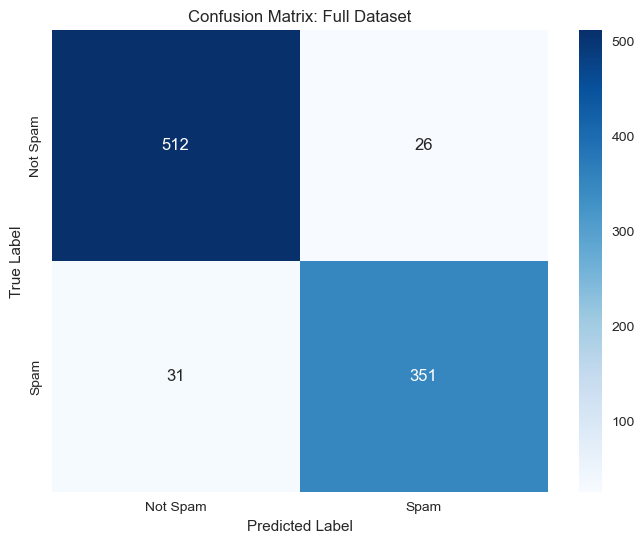

In [18]:
# TO DO: Print confusion matrix using a heatmap for validation data (1 mark)
# HINT: To remove scientific notation from a heatmap, set the parameter fmt='d'

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Full Dataset')
plt.show()

### Questions (8 marks)
1. How do the training and validation accuracy change depending on the amount of data used? Explain with values.
1. Why do the training and validation accuracy behave this way when the amount of data is changed? Relate your answer to concepts discussed in class.
1. Do these results change based on the `random_state` selected for splitting the data into X_small and y_small? Why do you think it behaves this way?
1. In this case, what do a false positive and a false negative represent? In your opinion, which one is worse?

*ANSWER HERE*
1. Accuracy Analysis:<br>
   `Full Dataset (57 features):` 4600 samples yield a training accuracy of 93.12% and a validation
accuracy of 91.26%.<br>
   `Reduced Features (First 10 columns):` 4600 samples yield a training accuracy of 79.36% and a validation
accuracy of 78.17%.<br>
   `Small Dataset (57 features):` 138 samples yield a training accuracy of 94.57% and a validation
accuracy of 88.31<br>
The training and validation accuracy are better when the sample size is bigger. However, even with a small sample size, it's possible to get a high training accuracy as long as it's not too small of a sample size. Validation accuracy, however, will properly reflect the sample size (if that makes sense).
2. There are two ways that `amount of data` could be measured: features and sample size. When there are fewer features, no matter the sample size, the model doesn't have enough information to define a boundary, leading to `underfitting`. On the other hand, a smaller sample size and enough features leads to `overfitting`, which is basically where the model just memorizes the pattern and tries to find that in the test/validation data sets.
3. Yes, the results for the small dataset would fluctuate significantly. With only 3% of the data, the specific samples selected are not highly representative of the entire population; a different `random_state` could pick a much easier or much harder subset to classify, leading to high sampling variance.
4. In the context of this dataset, a false positive means that a legitimate email is incorrectly filtered into the spam folder. A false negative means that a spam email is incorrectly let through into the main inbox. Using contextual clues, false positives are worse because the user could miss important communications, which carries far higher stakes than the minor inconvenience of a spam email that was missed.

### Process Description (4 marks)
Please describe the process you used to create your code. Cite any websites or generative AI tools used. You can use the following questions as guidance:
1. Where did you source your code?
1. In what order did you complete the steps?
1. If you used generative AI, what prompts did you use? Did you need to modify the code at all? Why or why not?
1. Did you have any challenges? If yes, what were they? If not, what helped you to be successful?

*DESCRIBE YOUR PROCESS HERE - BE SPECIFIC*
1. The code is primarily my own. I wrote the implementation myself, however, I also drew inspiration from concepts and examples covered in previous courses and from sample materials posted on D2L.
2. In the order listed in the notebook. Like Step 1, then Step 2, then Step 3, etc. Following the notebook order helped ensure that each model was trained and evaluated consistently before moving on to the next experiment.
3. I used generative AI to learn how to map using SNS <i>`How do I create a heatmap using seaborn (sns) in Python for a confusion matrix? Can you explain what each parameter does?`</i> and to fix the grammar in my answers here <i>`Can you fix the grammar in my answers without changing the tone or sentence structure?`</i>. I did not need to modify the code generated by the AI, since it was only used for understanding syntax and improving explanations rather than directly copying code into the notebook.
4. One of the few challenges was that I haven't really worked with SNS, and also it's been a while since I worked with Anaconda and Jupyter Notebook altogether. However, I have worked with scikit, so it was a nice refresher.

## Part 2: Regression (23 marks)

For this section, we will be using the auto-mpg dataset. You will need to repeat the steps from Part 1 for this analysis.

### Step 1: Data Input (0.5 marks)

The data used for this task can be downloaded from UCI website: https://archive.ics.uci.edu/ml/datasets/Auto%2BMPG 

Load the auto-mpg dataset and inspect the first few rows

In [19]:
# TO DO: Load the data (0.5 marks)
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

column_names = [
    'mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 
    'acceleration', 'model year', 'origin', 'car name'
]

df = pd.read_csv(url, names=column_names, sep='\s+', na_values='?')

# Inspect the first few rows
print(df.head())

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   model year  origin                   car name  
0          70       1  chevrolet chevelle malibu  
1          70       1          buick skylark 320  
2          70       1         plymouth satellite  
3          70       1              amc rebel sst  
4          70       1                ford torino  


### Step 2: Data Processing (2.5 marks)

Check to see if there are any missing values in the dataset. If necessary, select an appropriate method to fill-in the missing values.

In [20]:
# TO DO: Check if there are any missing values and fill them in if necessary (1 mark)
missing_counts = df.isnull().sum()
print("Missing values per column:")
print(missing_counts)

df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

print("\nMissing values after filling:")
print(df.isnull().sum())

Missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

Missing values after filling:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


Remove any columns that do not have numerical data.

In [21]:
# TO DO: Remove non-numeric data (0.5 marks)
df_numeric = df.drop(columns=['car name'])

print(df_numeric.head())
print("\nNew Data Types:")
print(df_numeric.dtypes)

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   model year  origin  
0          70       1  
1          70       1  
2          70       1  
3          70       1  
4          70       1  

New Data Types:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model year        int64
origin            int64
dtype: object


Split the auto-mpg data into the feature matrix and target vector. Inspect the first few columns of the feature matrix to make sure it split properly.

In [22]:
# TO DO: Create feature matrix and target vector (1 mark) 
y = df_numeric['mpg']

X = df_numeric.drop(columns=['mpg'])

print("Feature Matrix (X) - First 5 rows:")
print(X.head())

print("\nTarget Vector (y) - First 5 rows:")
print(y.head())

Feature Matrix (X) - First 5 rows:
   cylinders  displacement  horsepower  weight  acceleration  model year  \
0          8         307.0       130.0  3504.0          12.0          70   
1          8         350.0       165.0  3693.0          11.5          70   
2          8         318.0       150.0  3436.0          11.0          70   
3          8         304.0       150.0  3433.0          12.0          70   
4          8         302.0       140.0  3449.0          10.5          70   

   origin  
0       1  
1       1  
2       1  
3       1  
4       1  

Target Vector (y) - First 5 rows:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


### Step 3: Implement and Validate Machine Learning Model (3.5 marks)

1. Import any required libraries
1. Split the data into training and testing sets (testing data should be 10% of the dataset)
1. Instantiate model `LinearRegression()`
1. Train and validate the machine learning model using the training set (using `cross_validate()` with `cv=5` and `scoring='r2'`)
1. Print the training and validation accuracy 

In [23]:
# TO DO: ADD YOUR CODE HERE (2 marks)
# Note: for any random state parameters, you can use random_state = 0
import numpy as np
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=0)

model = LinearRegression()

cv_results = cross_validate(model, X_train, y_train, cv=5, scoring='r2', return_train_score=True)

train_accuracy = np.mean(cv_results['train_score'])
val_accuracy = np.mean(cv_results['test_score'])

print(f"Average Training Accuracy (R^2): {train_accuracy:.4f}")
print(f"Average Validation Accuracy (R^2): {val_accuracy:.4f}")

Average Training Accuracy (R^2): 0.8173
Average Validation Accuracy (R^2): 0.8078


Was using linear regression good enough? Let's try using Ridge Regression to see if adding regularization can improve model performance. For this case, let's try alpha = 0.01, 0.1, 1, 10 and 100. Print out the results for each case.

In [3]:
# TO DO: ADD YOUR CODE HERE (1.5 marks)
from sklearn.linear_model import Ridge

alphas = [0.01, 0.1, 1, 10, 100]

print(f"{'Alpha':<10} | {'Train R2':<12} | {'Val R2':<12}")
print("-" * 40)

for a in alphas:
    ridge_model = Ridge(alpha=a, random_state=0)
    
    cv_ridge = cross_validate(ridge_model, X_train, y_train, cv=5, scoring='r2', return_train_score=True)
    
    train_r2 = np.mean(cv_ridge['train_score'])
    val_r2 = np.mean(cv_ridge['test_score'])
    
    print(f"{a:<10} | {train_r2:<12.4f} | {val_r2:<12.4f}")

Alpha      | Train R2     | Val R2      
----------------------------------------


NameError: name 'cross_validate' is not defined

### Step 4: Test Model (1 mark)

What was the best model in this case? Using the best model, calculate the testing accuracy using the R^2 score

In [25]:
# TO DO: ADD YOUR CODE HERE
from sklearn.metrics import r2_score

best_model = Ridge(alpha=10, random_state=0)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
test_r2 = r2_score(y_test, y_pred)

print(f"The best model is Ridge Regression with alpha = 10.")
print(f"Final Testing Accuracy (R^2): {test_r2:.4f}")

The best model is Ridge Regression with alpha = 10.
Final Testing Accuracy (R^2): 0.8465


### Step 5: Visualize Results (1.5 marks)

1. Plot the relationship between each of the features and the target vector using `pairplot`
1. Plot the correlation matrix
1. Print the coefficients for each feature and the intercept

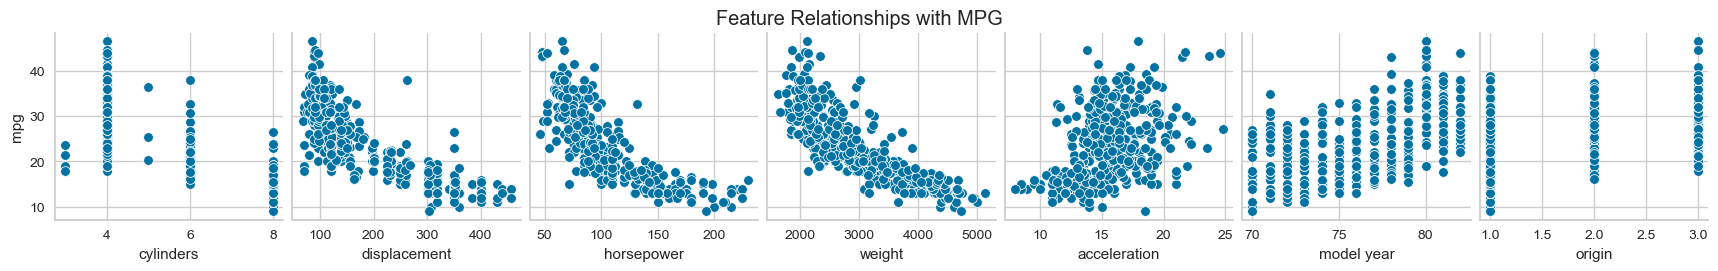

In [26]:
# TO DO: Plot pairplot (0.5 marks)
sns.pairplot(df_numeric, y_vars=['mpg'], x_vars=X.columns)
plt.suptitle("Feature Relationships with MPG", y=1.05)
plt.show()

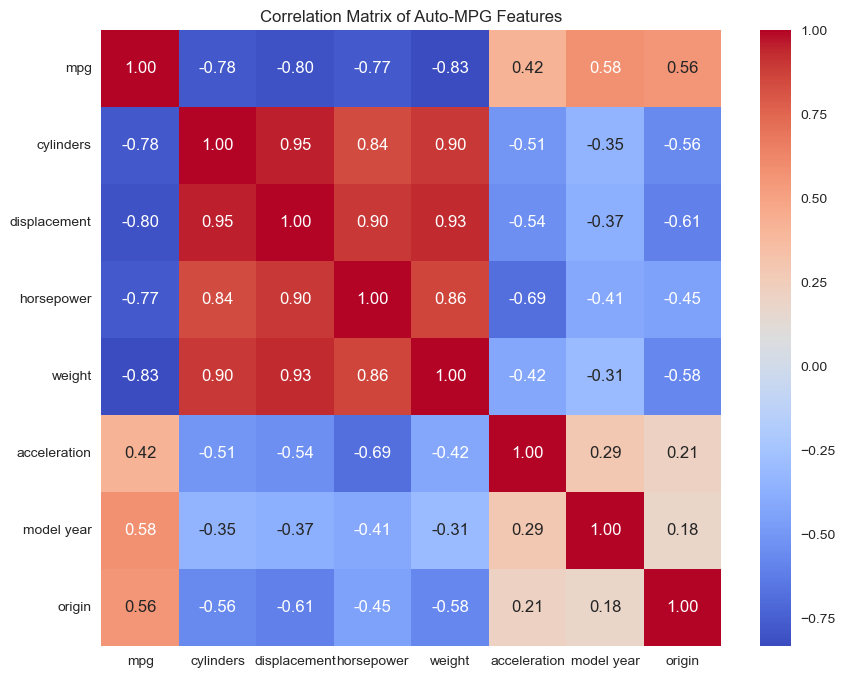

In [27]:
# TO DO: Plot correlation matrix (0.5 marks)
plt.figure(figsize=(10, 8))
correlation_matrix = df_numeric.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Auto-MPG Features")
plt.show()

In [28]:
# TO DO: Print model coefficients and intercept (0.5 marks)
print(f"Model Intercept: {best_model.intercept_:.4f}")
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, best_model.coef_):
    print(f"{feature:<15}: {coef:>10.4f}")

Model Intercept: -16.2705

Model Coefficients:
cylinders      :    -0.4643
displacement   :     0.0199
horsepower     :    -0.0183
weight         :    -0.0064
acceleration   :     0.1258
model year     :     0.7246
origin         :     1.4000


### Questions (10 marks)
1. What method did you use to fill in any missing data? Why did you select that method?
1. Did using linear regression produce good results for this dataset or did it overfit/underfit? Use the plots to explain why the linear model was or wasn't a good fit.
1. Do the coefficients for each of the features make sense when compared to the `pairplot` and the correlation matrix? Why or why not?
1. Does using ridge regression change the results significantly? What do you think is the cause of these (changed or unchanged) results?
1. Any suggestions as to what should we do to further improve these results?

*ANSWER HERE*
1. Well, there were no missing values to begin with. But if there were missing values, the method I would choose to fill those in is using the median values of the dataset. I would choose this because the median value is usually unaffected by outliers, which could be present in engine performance datasets. Using the mean would have skewed the data if the distribution was non-symmetric.
2. Linear regression produced strong results, achieving a validation R² of 0.8078, meaning it explains about 81% of the variance in MPG. The model is well-fit rather than overfit, as the training (0.8173) and validation scores are very close. However, the pairplots show a slight “bowed” curve in the relationship between weight and MPG, suggesting a linear model may slightly underfit the true non-linear nature of the data.
3. The coefficients generally align with the visual data, particularly the negative coefficient for weight (-0.0064), which matches its strong -0.83 correlation with MPG. However, displacement shows a small positive coefficient despite having a negative correlation. This is likely due to multicollinearity, where the model struggles to isolate the effect of displacement because it is so highly correlated with weight (0.93) and cylinders (0.95).
4. Using Ridge regression didn’t change the results significantly, really not at all. For alphas between 0.01 and 1, the R² stayed exactly the same. The cause of this is that the dataset has a relatively large number of samples compared to features, and the features are not so noisy that the model requires heavy regularization to prevent overfitting.
5. To further improve the 0.8465 testing R², we could implement Polynomial Features to capture the curved relationships seen in the weight and horsepower plots. Additionally, applying One-Hot Encoding to the origin and cylinders columns would treat them as distinct categories rather than continuous scales, potentially uncovering more precise patterns in fuel efficiency.

### Process Description (4 marks)
Please describe the process you used to create your code. Cite any websites or generative AI tools used. You can use the following questions as guidance:
1. Where did you source your code?
1. In what order did you complete the steps?
1. If you used generative AI, what prompts did you use? Did you need to modify the code at all? Why or why not?
1. Did you have any challenges? If yes, what were they? If not, what helped you to be successful?

*DESCRIBE YOUR PROCESS HERE - BE SPECIFIC*
1. The code is my own work. I refined parts of it using general guidance from generative AI tools, and I also drew inspiration from examples in previous courses and materials posted on D2L. I discussed some ideas with my cousin, but the implementation and final design were written by me.
2. In the order listed in the notebook. Like Step 1, then Step 2, then Step 3, etc. Following the notebook order helped ensure that each model was trained and evaluated consistently before moving on to the next experiment.
3. Not going to lie, I had to use generative AI a lot in this part. First of all, I didn’t know how to upload a dataset using a URL link through pandas, so I used GenAI with prompts like <i>`How do I load a UCI Archive dataset from a URL using pandas?`</i>. Another thing was that I had never worked with Ridge regression before, so I used GenAI to learn how it works and how to implement it, using prompts such as <i>`How does Ridge regression work in scikit-learn and how do I apply it to a dataset?`</i>. I also used GenAI to refine my code where necessary, asking things like <i>`Can you help clean up or improve this regression code?`</i>, and finally to fix the grammar in my written answers <i>`Can you fix the grammar in my answers without changing the tone or sentence structure?`</i>. I did need to slightly modify the generated code to better fit the structure of my notebook and match the variables I was already using.
4. Yes, I definitely had challenges. Like I mentioned earlier, I had no idea how to upload a dataset using a URL through pandas, and I had never worked with Ridge regression before. Those were probably the biggest challenges in this assignment. Using GenAI to explain concepts and provide examples helped me overcome those issues and move forward successfully.

## Part 3: Reflection (2 marks)
Include a sentence or two about:
- what you liked or disliked,
- found interesting, confusing, challenging, motivating
while working on this assignment.


*ADD YOUR THOUGHTS HERE*
- I really enjoyed working with scikit‑learn again after having used it briefly back in ENDG 319, so it was exciting to revisit it with a deeper understanding this time. It reminded me how powerful and intuitive the library can be once you get into the flow.
- Part 2, especially the regression component, was extremely challenging. I struggled at first, but working through those difficulties ended up being motivating because I learned a lot in the process and came out with a much stronger grasp of the concepts.